# CME538 Tutorial 11: Introduction to SQL

In this tutorial, you'll learn how **SQL (Structured Query Language)** can be used to work with data stored in relational databases.

We will use the **Chinook sample database** throughout the tutorial to learn how to:

- retrieve and filter data,
- sort and summarize records,
- aggregate data using groups,
- combine information from multiple tables using joins, and
- move query results between SQL and Python/Pandas.

The goal is to develop a practical understanding of SQL as another tool in the data-science workflow.

## Learning Objectives

By the end of this tutorial, you should be able to:

1. Explain the basic structure of a **relational database**.
2. Identify **tables, columns, primary keys, and foreign keys**.
3. Write SQL queries using `SELECT`, `FROM`, `WHERE`, `ORDER BY`, and `LIMIT`.
4. Summarize data using `COUNT`, `SUM`, `AVG`, `MIN`, and `MAX`.
5. Use `GROUP BY` and `HAVING` to analyze groups of records.
6. Combine related tables using `JOIN` and `ON`.
7. Transfer SQL query results into a **Pandas DataFrame** for further analysis.
8. Recognize how these same techniques can be applied to engineering datasets such as inspection records, project data, sensor measurements, and asset inventories.

> **Key idea:** SQL is not a replacement for Python. It is another tool in the data-science workflow, particularly useful for working with structured data stored in databases.

> **Tutorial context**
>
> This is an additional tutorial designed to introduce a modern data-management skill that is widely used alongside Python in data-science workflows. The examples use the Chinook sample database, but the same SQL concepts apply to engineering and infrastructure datasets.

# 1. Why SQL?

So far in this course, we have primarily worked with data stored in files such as CSV files and loaded those files into Python using Pandas.

This works well for many data-science tasks, but real-world data is often stored in **databases**.

A database allows us to store related information in a structured way and retrieve only the information we need.

For example, an engineering organization might store:

- projects,
- inspection records,
- materials,
- contractors,
- sensor measurements, and
- maintenance records

in separate but related tables.

Instead of loading every record into Python, we can use **SQL to ask the database for the specific information we need**.

## SQL and Pandas

SQL and Pandas can perform many similar operations, but they are designed for different parts of a data workflow.

| Task | SQL | Pandas |
|---|---|---|
| Select columns | `SELECT` | `df[[...]]` |
| Filter rows | `WHERE` | Boolean filtering |
| Sort data | `ORDER BY` | `.sort_values()` |
| Group data | `GROUP BY` | `.groupby()` |
| Aggregate data | `COUNT`, `SUM`, `AVG`, etc. | `.count()`, `.sum()`, `.mean()`, etc. |
| Further analysis | Limited | Extensive |
| Visualization | Limited | Strong |
| Machine learning | No | Strong |

A useful way to think about the relationship is:

**SQL retrieves and summarizes data → Pandas analyzes and visualizes the results.**

We will see this workflow near the end of the tutorial.

## Why not just use Pandas?

If the data is already stored in a database, it can be inefficient to load an entire database into Python just to select a few rows or calculate a simple summary.

SQL allows us to perform these operations **close to where the data is stored**.

For example, instead of:

1. loading a very large table into Pandas,
2. filtering millions of rows, and
3. keeping only a small result,

we can ask the database to perform the filtering first and return only the records we need.

This becomes particularly important as datasets grow in size and as data is shared across applications, analysts, and engineering teams.

## SQL in the modern data-science workflow

SQL is not limited to one database product.

You will encounter SQL with systems such as:

- **SQLite** — lightweight, file-based databases; useful for learning and small applications.
- **PostgreSQL** — a widely used open-source relational database.
- **MySQL** — another widely used relational database system.
- **SQL Server** and **Oracle** — common in enterprise environments.
- **DuckDB** — a modern analytical database designed to work especially well with local analytical data and data-science workflows.
- **Cloud data warehouses** — such as BigQuery, Snowflake, and others.

The SQL syntax is largely transferable between these systems, although each database can have its own extensions and differences.

For this tutorial, we will use **SQLite** because it allows us to work with a complete relational database without requiring a database server.

## Our Database: Chinook

For the rest of this tutorial, we will work with the **Chinook database**, a small sample relational database containing information about customers, invoices, tracks, albums, artists, and other entities.

Although the data is not from civil engineering, the database structure is representative of the kinds of relationships that appear in engineering information systems.

For example:

- a **customer** can have many **invoices**,
- an **album** can contain many **tracks**,
- an **artist** can have many **albums**, and
- a **track** belongs to a particular **album** and **media type**.

These relationships will give us a practical way to learn how SQL queries work across multiple tables.

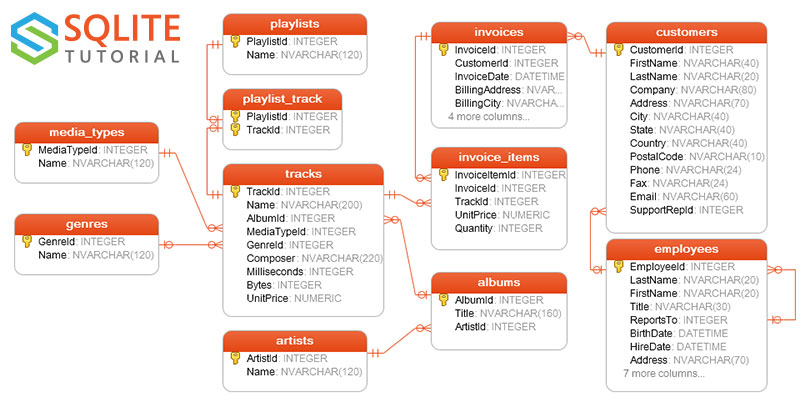

# 2. Relational Databases and the Chinook Schema

A **relational database** stores information in tables.

A table is similar to a Pandas DataFrame:

- **Rows** represent individual records.
- **Columns** represent attributes of those records.
- Each table represents a particular entity or type of information.

For example, the `customers` table contains information about customers, while the `invoices` table contains information about invoices.

## Primary Keys and Foreign Keys

A **primary key** uniquely identifies a record within a table.

For example, `CustomerId` identifies a particular customer in the `customers` table.

A **foreign key** is a column that refers to a key in another table.

For example, the `invoices` table also contains `CustomerId`. This allows the database to connect an invoice to the customer who made the purchase.

> **Primary key:** identifies a record in its own table.  
> **Foreign key:** references a record in another table.

## Why Multiple Tables?

Instead of storing everything in one large table, a relational database separates information into related tables.

For example:

```text
customers
    |
    | CustomerId
    v
invoices

In [1]:
# Import SQLite's built-in Python library
import sqlite3

# Import Pandas for working with query results
import pandas as pd

# Connect to the Chinook SQLite database
# The database file should be in the same folder as this notebook
conn = sqlite3.connect("chinook.db")

In [2]:
# Query SQLite's system table to find all tables in the database
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", conn)

# Display the table names
tables

,name
0,albums
1,artists
2,customers
3,employees
4,genres
5,invoice_items
6,invoices
7,media_types
8,playlist_track
9,playlists


# 3. Writing SQL Queries

Now that we have connected to the SQLite database, we can start querying the data.

We will build SQL queries incrementally, starting with:

- `SELECT` — choose columns
- `FROM` — choose the table
- `LIMIT` — restrict the number of rows returned
- `WHERE` — filter rows
- `ORDER BY` — sort results
- `DISTINCT` — return unique values

The goal is to learn the core SQL pattern before combining multiple operations.

## Our First SQL Query

The basic structure of a SQL query is:

```sql
SELECT columns
FROM table;

In [4]:
# Retrieve all columns and rows from the customers table
query = """
SELECT *
FROM customers;
"""

# Execute the SQL query and return the result as a Pandas DataFrame
customers = pd.read_sql(query, conn)

# Display the result
customers

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,NaN,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,+49 0711 2842222,NaN,leonekohler@surfeu.de,5
2,3,François,Tremblay,NaN,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,NaN,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,NaN,Ullevålsveien 14,Oslo,NaN,Norway,0171,+47 22 44 22 22,NaN,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,NaN,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4
5,6,Helena,Holý,NaN,Rilská 3174/6,Prague,NaN,Czech Republic,14300,+420 2 4177 0449,NaN,hholy@gmail.com,5
6,7,Astrid,Gruber,NaN,"Rotenturmstraße 4, 1010 Innere Stadt",Vienne,NaN,Austria,1010,+43 01 5134505,NaN,astrid.gruber@apple.at,5
7,8,Daan,Peeters,NaN,Grétrystraat 63,Brussels,NaN,Belgium,1000,+32 02 219 03 03,NaN,daan_peeters@apple.be,4
8,9,Kara,Nielsen,NaN,Sønder Boulevard 51,Copenhagen,NaN,Denmark,1720,+453 3331 9991,NaN,kara.nielsen@jubii.dk,4
9,10,Eduardo,Martins,Woodstock Discos,"Rua Dr. Falcão Filho, 155",São Paulo,SP,Brazil,01007-010,+55 (11) 3033-5446,+55 (11) 3033-4564,eduardo@woodstock.com.br,4


### `SELECT *`

The `*` means **all columns**.

Although `SELECT *` is useful when exploring a database, it is usually better to request only the columns we actually need when working with larger datasets.

For example, suppose we only want to see each customer's name, city, and country.

In [5]:
# Select only the columns needed for our analysis
query = """
SELECT FirstName, LastName, City, Country
FROM customers;
"""

# Run the query and store the result as a DataFrame
customer_locations = pd.read_sql(query, conn)

# Display the selected columns
customer_locations

,FirstName,LastName,City,Country
0,Luís,Gonçalves,São José dos Campos,Brazil
1,Leonie,Köhler,Stuttgart,Germany
2,François,Tremblay,Montréal,Canada
3,Bjørn,Hansen,Oslo,Norway
4,František,Wichterlová,Prague,Czech Republic
5,Helena,Holý,Prague,Czech Republic
6,Astrid,Gruber,Vienne,Austria
7,Daan,Peeters,Brussels,Belgium
8,Kara,Nielsen,Copenhagen,Denmark
9,Eduardo,Martins,São Paulo,Brazil


## Limiting the Number of Rows

When exploring a large table, we usually do not want to display every record.

The `LIMIT` clause restricts the number of rows returned by the query.

This is similar to using `df.head()` in Pandas.

In [6]:
# Select all columns from customers, but return only the first 10 rows
query = """
SELECT *
FROM customers
LIMIT 10;
"""

# Execute the query
customers_10 = pd.read_sql(query, conn)

# Display the first 10 records
customers_10

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,NaN,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,+49 0711 2842222,NaN,leonekohler@surfeu.de,5
2,3,François,Tremblay,NaN,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,NaN,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,NaN,Ullevålsveien 14,Oslo,NaN,Norway,0171,+47 22 44 22 22,NaN,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,NaN,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4
5,6,Helena,Holý,NaN,Rilská 3174/6,Prague,NaN,Czech Republic,14300,+420 2 4177 0449,NaN,hholy@gmail.com,5
6,7,Astrid,Gruber,NaN,"Rotenturmstraße 4, 1010 Innere Stadt",Vienne,NaN,Austria,1010,+43 01 5134505,NaN,astrid.gruber@apple.at,5
7,8,Daan,Peeters,NaN,Grétrystraat 63,Brussels,NaN,Belgium,1000,+32 02 219 03 03,NaN,daan_peeters@apple.be,4
8,9,Kara,Nielsen,NaN,Sønder Boulevard 51,Copenhagen,NaN,Denmark,1720,+453 3331 9991,NaN,kara.nielsen@jubii.dk,4
9,10,Eduardo,Martins,Woodstock Discos,"Rua Dr. Falcão Filho, 155",São Paulo,SP,Brazil,01007-010,+55 (11) 3033-5446,+55 (11) 3033-4564,eduardo@woodstock.com.br,4


## Filtering Rows with `WHERE`

`WHERE` allows us to filter individual rows based on a condition.

For example, we can find customers who live in Canada.

The general pattern is:

```sql
SELECT columns
FROM table
WHERE condition;

In [8]:

# Select customers whose country is Canada
query = """
SELECT FirstName, LastName, City, Country
FROM customers
WHERE Country = 'Canada';
"""

# Execute the query and store the result
canadian_customers = pd.read_sql(query, conn)

# Display the matching records
canadian_customers

,FirstName,LastName,City,Country
0,François,Tremblay,Montréal,Canada
1,Mark,Philips,Edmonton,Canada
2,Jennifer,Peterson,Vancouver,Canada
3,Robert,Brown,Toronto,Canada
4,Edward,Francis,Ottawa,Canada
5,Martha,Silk,Halifax,Canada
6,Aaron,Mitchell,Winnipeg,Canada
7,Ellie,Sullivan,Yellowknife,Canada


### Filtering Numeric Values

`WHERE` can also be used with numerical conditions.

For example, the `invoices` table contains the total value of each invoice.

We can find invoices with a total greater than $10.

In [9]:
# Select invoices with a total greater than 10
query = """
SELECT InvoiceId, CustomerId, Total
FROM invoices
WHERE Total > 10
LIMIT 10;
"""

# Execute the query
large_invoices = pd.read_sql(query, conn)

# Display the first 10 matching invoices
large_invoices

,InvoiceId,CustomerId,Total
0,5,23,13.86
1,12,2,13.86
2,19,40,13.86
3,26,19,13.86
4,33,57,13.86
5,40,36,13.86
6,47,15,13.86
7,54,53,13.86
8,61,32,13.86
9,68,11,13.86


## Sorting Results with `ORDER BY`

`ORDER BY` sorts the rows returned by a query.

By default, the order is **ascending** (`ASC`).

We can use `DESC` to sort from largest to smallest, or from Z to A.

For example, let's find the largest invoices in the database.

In [10]:
# Select invoices and sort them from largest to smallest
query = """
SELECT InvoiceId, CustomerId, Total
FROM invoices
ORDER BY Total DESC
LIMIT 10;
"""

# Execute the query
largest_invoices = pd.read_sql(query, conn)

# Display the 10 largest invoices
largest_invoices

,InvoiceId,CustomerId,Total
0,404,6,25.86
1,299,26,23.86
2,96,45,21.86
3,194,46,21.86
4,89,7,18.86
5,201,25,18.86
6,88,57,17.91
7,306,5,16.86
8,313,43,16.86
9,103,24,15.86


## Combining SQL Clauses

SQL becomes powerful when we combine these operations.

A common pattern is:

```text
SELECT
FROM
WHERE
ORDER BY
LIMIT

In [11]:

# Find Canadian invoices with totals greater than 1
# and return the five largest invoices
query = """
SELECT InvoiceId, CustomerId, BillingCountry, Total
FROM invoices
WHERE BillingCountry = 'Canada'
  AND Total > 1
ORDER BY Total DESC
LIMIT 5;
"""

# Execute the query
canadian_invoices = pd.read_sql(query, conn)

# Display the results
canadian_invoices

,InvoiceId,CustomerId,BillingCountry,Total
0,47,15,Canada,13.86
1,61,32,Canada,13.86
2,110,3,Canada,13.86
3,159,33,Canada,13.86
4,180,29,Canada,13.86


### Quick Exercise

Modify the query above to find the **five smallest invoices from Canada**.

**Hint:** You only need to change the sorting direction.

Try it yourself before looking at the solution.

In [13]:
# Find the five smallest invoices from Canada
query = """
SELECT InvoiceId, CustomerId, BillingCountry, Total
FROM invoices
WHERE BillingCountry = 'Canada'
  AND Total > 1
ORDER BY Total ASC
LIMIT 5;
"""

# Execute the query
smallest_canadian_invoices = pd.read_sql(query, conn)

# Display the results
smallest_canadian_invoices

,InvoiceId,CustomerId,BillingCountry,Total
0,36,15,Canada,1.98
1,49,30,Canada,1.98
2,50,32,Canada,1.98
3,133,14,Canada,1.98
4,147,31,Canada,1.98


# 4. Summarizing Data with SQL

So far, our queries have returned individual records.

In data science, we often want summaries instead:

- How many records are there?
- What is the total?
- What is the average?
- What is the minimum or maximum?
- How many unique categories are present?

SQL provides aggregate functions for these tasks:

| Function | Purpose |
|---|---|
| `COUNT()` | Count records |
| `SUM()` | Add values |
| `AVG()` | Calculate an average |
| `MIN()` | Find the minimum |
| `MAX()` | Find the maximum |

We will also use `DISTINCT` to identify unique values.

## `DISTINCT`: Finding Unique Values

`DISTINCT` removes duplicate values from the query result.

For example, the `customers` table contains customers from multiple countries. We can use `DISTINCT` to see which countries are represented.

In [14]:
# Find the unique countries represented in the customers table
query = """
SELECT DISTINCT Country
FROM customers
ORDER BY Country;
"""

# Execute the query and store the result
countries = pd.read_sql(query, conn)

# Display the unique countries
countries

,Country
0,Argentina
1,Australia
2,Austria
3,Belgium
4,Brazil
5,Canada
6,Chile
7,Czech Republic
8,Denmark
9,Finland


### Counting Unique Values

We can combine `COUNT()` and `DISTINCT` to determine how many unique countries are represented.

This is different from counting all customer records.

In [15]:
# Count the number of unique countries in the customers table
query = """
SELECT COUNT(DISTINCT Country) AS NumberOfCountries
FROM customers;
"""

# Execute the query
country_count = pd.read_sql(query, conn)

# Display the result
country_count

,NumberOfCountries
0,24


## `COUNT()`

`COUNT()` tells us how many records satisfy a condition.

For example, we can count the total number of invoices in the database.

In [16]:
# Count all invoice records
query = """
SELECT COUNT(*) AS NumberOfInvoices
FROM invoices;
"""

# Execute the query
invoice_count = pd.read_sql(query, conn)

# Display the result
invoice_count

,NumberOfInvoices
0,412


## Other Aggregate Functions

We can also calculate statistics for a numerical column.

For the `Total` column in `invoices`, we can calculate:

- the total amount using `SUM()`,
- the average invoice using `AVG()`,
- the smallest invoice using `MIN()`, and
- the largest invoice using `MAX()`.

In [17]:
# Calculate summary statistics for invoice totals
query = """
SELECT
    COUNT(*) AS NumberOfInvoices,
    SUM(Total) AS TotalRevenue,
    AVG(Total) AS AverageInvoice,
    MIN(Total) AS MinimumInvoice,
    MAX(Total) AS MaximumInvoice
FROM invoices;
"""

# Execute the query
invoice_summary = pd.read_sql(query, conn)

# Display the summary statistics
invoice_summary

,NumberOfInvoices,TotalRevenue,AverageInvoice,MinimumInvoice,MaximumInvoice
0,412,2328.6,5.651942,0.99,25.86


## Renaming Results with `AS`

SQL allows us to give columns a more useful name using `AS`.

For example:

```sql
AVG(Total) AS AverageInvoice

## A First Engineering Connection

Imagine that `invoices` were instead an engineering table containing project costs.

The same SQL operations could answer questions such as:

- How many projects are recorded?
- What is the total project cost?
- What is the average project cost?
- What is the largest project?
- What is the smallest project?

The database does not need to contain engineering data for these SQL concepts to transfer to an engineering setting.

### Quick Exercise

Using the `invoices` table, calculate:

1. the number of invoices,
2. the total invoice amount, and
3. the average invoice amount.

Try writing the query yourself before moving on.

**Hint:** You can calculate all three values in the same `SELECT` statement.

In [18]:
# Calculate the number, total, and average value of all invoices
query = """
SELECT
    COUNT(*) AS NumberOfInvoices,
    SUM(Total) AS TotalRevenue,
    AVG(Total) AS AverageInvoice
FROM invoices;
"""

# Execute the query
invoice_statistics = pd.read_sql(query, conn)

# Display the results
invoice_statistics

,NumberOfInvoices,TotalRevenue,AverageInvoice
0,412,2328.6,5.651942


## From Overall Summaries to Grouped Summaries

The calculations above describe the **entire table**.

Often, we want the same calculation for different groups.

For example:

> How many invoices does each country have?

This is where `GROUP BY` becomes important.

`GROUP BY` divides the rows into groups based on one or more columns and allows aggregate functions to be calculated separately for each group.

In [19]:
# Count invoices separately for each billing country
query = """
SELECT
    BillingCountry,
    COUNT(*) AS NumberOfInvoices
FROM invoices
GROUP BY BillingCountry
ORDER BY NumberOfInvoices DESC
LIMIT 10;
"""

# Execute the grouped query
invoices_by_country = pd.read_sql(query, conn)

# Display the countries with the most invoices
invoices_by_country

,BillingCountry,NumberOfInvoices
0,USA,91
1,Canada,56
2,France,35
3,Brazil,35
4,Germany,28
5,United Kingdom,21
6,Portugal,14
7,Czech Republic,14
8,India,13
9,Sweden,7


The result contains one row for each country.

This is conceptually similar to a Pandas `groupby()` operation:

```python
df.groupby("BillingCountry").size()

### Key Idea

`COUNT()`, `SUM()`, `AVG()`, `MIN()`, and `MAX()` summarize data.

`GROUP BY` tells SQL **which groups should receive their own summary**.

Next, we will see how to filter these groups using `HAVING`.

# 5. Grouped Analysis with `GROUP BY` and `HAVING`

We can use `GROUP BY` to calculate separate summaries for different groups.

For example, instead of asking:

> How many invoices are in the database?

we can ask:

> How many invoices does each country have?

The basic pattern is:

```sql
SELECT group_column, AGGREGATE_FUNCTION(...)
FROM table
GROUP BY group_column;

In [20]:
# Count invoices for each billing country
query = """
SELECT
    BillingCountry,
    COUNT(*) AS NumberOfInvoices
FROM invoices
GROUP BY BillingCountry
ORDER BY NumberOfInvoices DESC;
"""

# Execute the grouped query
invoices_by_country = pd.read_sql(query, conn)

# Display the results
invoices_by_country

,BillingCountry,NumberOfInvoices
0,USA,91
1,Canada,56
2,France,35
3,Brazil,35
4,Germany,28
5,United Kingdom,21
6,Portugal,14
7,Czech Republic,14
8,India,13
9,Sweden,7


## Filtering Groups with `HAVING`

Suppose we only want countries with **more than 5 invoices**.

`WHERE` cannot be used to filter the result of an aggregate calculation such as `COUNT()`.

Instead, we use `HAVING`.

In [21]:
# Find countries with more than 5 invoices
query = """
SELECT
    BillingCountry,
    COUNT(*) AS NumberOfInvoices
FROM invoices
GROUP BY BillingCountry
HAVING COUNT(*) > 5
ORDER BY NumberOfInvoices DESC;
"""

# Execute the query
countries_with_many_invoices = pd.read_sql(query, conn)

# Display the filtered groups
countries_with_many_invoices

,BillingCountry,NumberOfInvoices
0,USA,91
1,Canada,56
2,France,35
3,Brazil,35
4,Germany,28
5,United Kingdom,21
6,Portugal,14
7,Czech Republic,14
8,India,13
9,Sweden,7


### `WHERE` vs. `HAVING`

A useful rule is:

```text
WHERE   → filters individual rows
GROUP BY → creates groups
HAVING  → filters groups


SELECT BillingCountry, COUNT(*)
FROM invoices
WHERE Total > 5
GROUP BY BillingCountry
HAVING COUNT(*) > 5;

In [23]:
# First keep invoices larger than 5,
# then group them by country,
# and finally keep only countries with more than 5 such invoices
query = """
SELECT
    BillingCountry,
    COUNT(*) AS NumberOfInvoices,
    SUM(Total) AS TotalRevenue
FROM invoices
WHERE Total > 5
GROUP BY BillingCountry
HAVING COUNT(*) > 5
ORDER BY TotalRevenue DESC;
"""

# Execute the complete grouped query
country_summary = pd.read_sql(query, conn)

# Display the results
country_summary

,BillingCountry,NumberOfInvoices,TotalRevenue
0,USA,40,406.19
1,Canada,24,230.68
2,France,15,146.55
3,Brazil,15,143.55
4,Germany,12,120.84
5,United Kingdom,9,86.13
6,Czech Republic,6,72.42
7,Portugal,6,59.42
8,India,6,57.42


### Quick Exercise

Modify the query above so that it returns only countries where the **total invoice amount exceeds 100**.

**Hint:** The condition belongs in `HAVING`, because `SUM(Total)` is an aggregate.

In [24]:
# Keep groups whose total invoice amount exceeds 100
query = """
SELECT
    BillingCountry,
    COUNT(*) AS NumberOfInvoices,
    SUM(Total) AS TotalRevenue
FROM invoices
GROUP BY BillingCountry
HAVING SUM(Total) > 100
ORDER BY TotalRevenue DESC;
"""

# Execute the query
high_revenue_countries = pd.read_sql(query, conn)

# Display the results
high_revenue_countries

,BillingCountry,NumberOfInvoices,TotalRevenue
0,USA,91,523.06
1,Canada,56,303.96
2,France,35,195.10
3,Brazil,35,190.10
4,Germany,28,156.48
5,United Kingdom,21,112.86


# 6. Joining Tables

A relational database usually stores different types of information in separate tables.

For example, in Chinook:

- `customers` stores customer information,
- `invoices` stores invoice information, and
- `tracks` stores information about individual tracks.

These tables are connected through **keys**.

A **primary key** uniquely identifies a record in a table.

A **foreign key** stores a value that refers to a record in another table.

For example:

```text
customers
CustomerId  ← primary key

invoices
CustomerId  ← foreign key


### Markdown cell

```markdown id="j1join"
## `JOIN` and `ON`

A `JOIN` combines rows from related tables.

The `ON` clause tells SQL **how the tables are related**.

The basic pattern is:

```sql
SELECT columns
FROM table1
JOIN table2
ON table1.key = table2.key;

In [25]:
# Join customers with their invoices using CustomerId
query = """
SELECT
    customers.CustomerId,
    customers.FirstName,
    customers.LastName,
    invoices.InvoiceId,
    invoices.InvoiceDate,
    invoices.Total
FROM customers
JOIN invoices
    ON customers.CustomerId = invoices.CustomerId
LIMIT 10;
"""

# Execute the join query
customer_invoices = pd.read_sql(query, conn)

# Display the combined records
customer_invoices

,CustomerId,FirstName,LastName,InvoiceId,InvoiceDate,Total
0,1,Luís,Gonçalves,98,2010-03-11 00:00:00,3.98
1,1,Luís,Gonçalves,121,2010-06-13 00:00:00,3.96
2,1,Luís,Gonçalves,143,2010-09-15 00:00:00,5.94
3,1,Luís,Gonçalves,195,2011-05-06 00:00:00,0.99
4,1,Luís,Gonçalves,316,2012-10-27 00:00:00,1.98
5,1,Luís,Gonçalves,327,2012-12-07 00:00:00,13.86
6,1,Luís,Gonçalves,382,2013-08-07 00:00:00,8.91
7,2,Leonie,Köhler,1,2009-01-01 00:00:00,1.98
8,2,Leonie,Köhler,12,2009-02-11 00:00:00,13.86
9,2,Leonie,Köhler,67,2009-10-12 00:00:00,8.91


Notice that one customer can appear multiple times because a customer can have multiple invoices.

This is an important feature of relational databases:

**one record in one table can be related to many records in another table.**

In [26]:
# Use table aliases to make a longer JOIN easier to read
query = """
SELECT
    c.FirstName,
    c.LastName,
    i.InvoiceDate,
    i.Total
FROM customers AS c
JOIN invoices AS i
    ON c.CustomerId = i.CustomerId
ORDER BY i.Total DESC
LIMIT 10;
"""

# Execute the query
top_customer_invoices = pd.read_sql(query, conn)

# Display the largest invoices with customer information
top_customer_invoices

,FirstName,LastName,InvoiceDate,Total
0,Helena,Holý,2013-11-13 00:00:00,25.86
1,Richard,Cunningham,2012-08-05 00:00:00,23.86
2,Ladislav,Kovács,2010-02-18 00:00:00,21.86
3,Hugh,O'Reilly,2011-04-28 00:00:00,21.86
4,Astrid,Gruber,2010-01-18 00:00:00,18.86
5,Victor,Stevens,2011-05-29 00:00:00,18.86
6,Luis,Rojas,2010-01-13 00:00:00,17.91
7,František,Wichterlová,2012-09-05 00:00:00,16.86
8,Isabelle,Mercier,2012-10-06 00:00:00,16.86
9,Bjørn,Hansen,2011-06-29 00:00:00,15.86


## `LEFT JOIN`

An `INNER JOIN` returns only matching records.

A `LEFT JOIN` keeps **all records from the left table**, even when there is no matching record in the right table.

This is useful when the question is:

> "Show me every customer, including customers who have no matching invoice."

The Chinook database provides a useful example because we can preserve the complete customer list while attaching invoice information when it exists.

In [27]:
# Keep every customer and attach matching invoice information
query = """
SELECT
    c.CustomerId,
    c.FirstName,
    c.LastName,
    i.InvoiceId,
    i.Total
FROM customers AS c
LEFT JOIN invoices AS i
    ON c.CustomerId = i.CustomerId
LIMIT 10;
"""

# Execute the LEFT JOIN
all_customers = pd.read_sql(query, conn)

# Display the results
all_customers

,CustomerId,FirstName,LastName,InvoiceId,Total
0,1,Luís,Gonçalves,98,3.98
1,1,Luís,Gonçalves,121,3.96
2,1,Luís,Gonçalves,143,5.94
3,1,Luís,Gonçalves,195,0.99
4,1,Luís,Gonçalves,316,1.98
5,1,Luís,Gonçalves,327,13.86
6,1,Luís,Gonçalves,382,8.91
7,2,Leonie,Köhler,1,1.98
8,2,Leonie,Köhler,12,13.86
9,2,Leonie,Köhler,67,8.91


## Joining More Than Two Tables

We can also connect several tables in one query.

For example, `tracks` contains a `MediaTypeId`, while `media_types` contains the corresponding description.

We can join them to make the result easier to interpret.

In [28]:
# Join tracks with media_types to replace an ID with its description
query = """
SELECT
    t.Name AS Track,
    m.Name AS MediaType
FROM tracks AS t
JOIN media_types AS m
    ON t.MediaTypeId = m.MediaTypeId
LIMIT 10;
"""

# Execute the multi-table query
tracks_with_media = pd.read_sql(query, conn)

# Display the result
tracks_with_media

,Track,MediaType
0,For Those About To Rock (We Salute You),MPEG audio file
1,Put The Finger On You,MPEG audio file
2,Let's Get It Up,MPEG audio file
3,Inject The Venom,MPEG audio file
4,Snowballed,MPEG audio file
5,Evil Walks,MPEG audio file
6,C.O.D.,MPEG audio file
7,Breaking The Rules,MPEG audio file
8,Night Of The Long Knives,MPEG audio file
9,Spellbound,MPEG audio file


### Quick Exercise

Using `customers` and `invoices`, find the **10 largest invoices** and include:

- customer first name,
- customer last name,
- invoice date, and
- invoice total.

Use a `JOIN`, then sort by invoice total in descending order.

In [29]:
# Find the 10 largest invoices and include customer information
query = """
SELECT
    c.FirstName,
    c.LastName,
    i.InvoiceDate,
    i.Total
FROM customers AS c
JOIN invoices AS i
    ON c.CustomerId = i.CustomerId
ORDER BY i.Total DESC
LIMIT 10;
"""

# Execute the query
largest_customer_invoices = pd.read_sql(query, conn)

# Display the results
largest_customer_invoices

,FirstName,LastName,InvoiceDate,Total
0,Helena,Holý,2013-11-13 00:00:00,25.86
1,Richard,Cunningham,2012-08-05 00:00:00,23.86
2,Ladislav,Kovács,2010-02-18 00:00:00,21.86
3,Hugh,O'Reilly,2011-04-28 00:00:00,21.86
4,Astrid,Gruber,2010-01-18 00:00:00,18.86
5,Victor,Stevens,2011-05-29 00:00:00,18.86
6,Luis,Rojas,2010-01-13 00:00:00,17.91
7,František,Wichterlová,2012-09-05 00:00:00,16.86
8,Isabelle,Mercier,2012-10-06 00:00:00,16.86
9,Bjørn,Hansen,2011-06-29 00:00:00,15.86


## From SQL Back to Python

SQL is excellent for retrieving and summarizing structured data.

Once we have the result we need, we can bring it into Pandas for:

- visualization,
- statistical analysis, and
- machine learning.

Next, we will connect SQL directly to a Pandas workflow.

# 7. SQL → Pandas

SQL is useful for retrieving and summarizing data, while Pandas is useful for further analysis and visualization.

A common data-science workflow is:

**Database → SQL query → Pandas DataFrame → analysis / visualization / machine learning**

We can use `pd.read_sql()` to execute a SQL query and immediately store the result as a Pandas DataFrame.

In [30]:
# Write a SQL query that summarizes invoice data by customer
query = """
SELECT
    CustomerId,
    COUNT(*) AS NumberOfInvoices,
    SUM(Total) AS TotalSpent,
    AVG(Total) AS AverageInvoice
FROM invoices
GROUP BY CustomerId
ORDER BY TotalSpent DESC
LIMIT 10;
"""

# Execute the SQL query and return the result as a Pandas DataFrame
df_customer_summary = pd.read_sql(query, conn)

# Display the resulting DataFrame
df_customer_summary

,CustomerId,NumberOfInvoices,TotalSpent,AverageInvoice
0,6,7,49.62,7.088571
1,26,7,47.62,6.802857
2,57,7,46.62,6.660000
3,45,7,45.62,6.517143
4,46,7,45.62,6.517143
5,24,7,43.62,6.231429
6,28,7,43.62,6.231429
7,37,7,43.62,6.231429
8,7,7,42.62,6.088571
9,25,7,42.62,6.088571


The result is now a regular Pandas DataFrame, so we can continue using the Python tools from the rest of the course.

For example, we can quickly visualize the summarized results.

NameError: name 'plt' is not defined

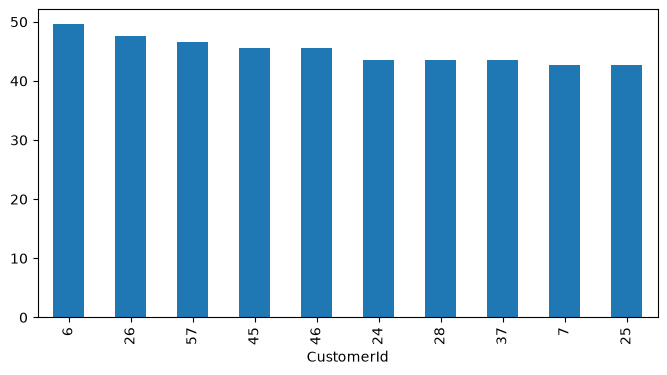

In [31]:
# Plot total spending for the customers returned by our SQL query
df_customer_summary.plot(
    x="CustomerId",
    y="TotalSpent",
    kind="bar",
    legend=False,
    figsize=(8, 4)
)

# Add labels to make the plot easier to interpret
plt.ylabel("Total spent")
plt.xlabel("Customer ID")
plt.title("Top Customers by Total Invoice Value")
plt.tight_layout()
plt.show()

# 8. Creating and Updating a Database

So far, we have queried an existing database.

In practice, data scientists may also need to **create tables and store processed data** in a database.

Pandas provides a convenient way to write a DataFrame into a SQL table using `to_sql()`.

We will create a small database containing a summary of our customer data.

In [32]:
# Create a new SQLite database for our processed results
output_conn = sqlite3.connect("cme538_results.db")

# Save the Pandas DataFrame as a SQL table
df_customer_summary.to_sql(
    name="customer_summary",
    con=output_conn,
    if_exists="replace",
    index=False
)

# Read the newly created table back from SQL
check_query = """
SELECT *
FROM customer_summary
ORDER BY TotalSpent DESC;
"""

# Load the SQL table back into Pandas to verify that it was saved
saved_summary = pd.read_sql(check_query, output_conn)

# Display the saved data
saved_summary

,CustomerId,NumberOfInvoices,TotalSpent,AverageInvoice
0,6,7,49.62,7.088571
1,26,7,47.62,6.802857
2,57,7,46.62,6.660000
3,45,7,45.62,6.517143
4,46,7,45.62,6.517143
5,24,7,43.62,6.231429
6,28,7,43.62,6.231429
7,37,7,43.62,6.231429
8,7,7,42.62,6.088571
9,25,7,42.62,6.088571


### Creating a Table Directly with SQL

We can also create a table directly using SQL.

The basic pattern is:

```sql
CREATE TABLE table_name (
    column1 data_type,
    column2 data_type
);

In [33]:
# Create a small engineering-style table directly with SQL
cursor = output_conn.cursor()

# Create the table if it does not already exist
cursor.execute("""
CREATE TABLE IF NOT EXISTS inspection_summary (
    InspectionID INTEGER,
    ProjectName TEXT,
    ConditionScore REAL
);
""")

# Insert a few example records
cursor.executemany(
    """
    INSERT INTO inspection_summary
    VALUES (?, ?, ?);
    """,
    [
        (1, "Bridge A", 82.5),
        (2, "Bridge B", 67.0),
        (3, "Bridge C", 91.5)
    ]
)

# Save the changes to the database
output_conn.commit()

# Query the newly created table
inspection_df = pd.read_sql(
    "SELECT * FROM inspection_summary;",
    output_conn
)

# Display the records
inspection_df

,InspectionID,ProjectName,ConditionScore
0,1,Bridge A,82.5
1,2,Bridge B,67.0
2,3,Bridge C,91.5


# 9. Wrap-Up

We have now seen the core SQL workflow:

1. **Connect** to a relational database.
2. **SELECT** the information we need.
3. **WHERE** filters individual rows.
4. **ORDER BY** sorts the results.
5. **GROUP BY** creates groups for analysis.
6. **HAVING** filters groups after aggregation.
7. **JOIN** combines related tables.
8. **Aggregate functions** such as `COUNT`, `SUM`, `AVG`, `MIN`, and `MAX` summarize data.
9. **Pandas** can receive SQL query results for visualization and further analysis.
10. **SQL tables** can also be created and populated from Python.

### The bigger data-science workflow

A useful mental model is:

**Raw data → Database → SQL → Pandas → Visualization / Statistics / Machine Learning**

SQL therefore complements the Python skills developed throughout this course.

### Civil Engineering Connection

The same workflow can support tasks such as:

- querying infrastructure inspection records,
- summarizing material test results,
- combining project and asset information,
- filtering sensor measurements,
- identifying assets requiring maintenance, and
- preparing data for machine-learning models.

The dataset changes, but the underlying data-management principles remain the same.

In [34]:
# Quick exercise:
# Modify the query below to find the five customers
# with the highest average invoice value.

query = """
SELECT
    CustomerId,
    AVG(Total) AS AverageInvoice
FROM invoices
GROUP BY CustomerId
ORDER BY AverageInvoice DESC
LIMIT 5;
"""

# Run the query and return the result as a Pandas DataFrame
exercise_result = pd.read_sql(query, conn)

# Display the result
exercise_result

,CustomerId,AverageInvoice
0,6,7.088571
1,26,6.802857
2,57,6.660000
3,45,6.517143
4,46,6.517143
